In [67]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *

In [68]:
class ObservableDataset(Dataset):
	"""
	Converts observable dataset into PyTorch syntax.
	"""
	def __init__(self, data):
		self.data = data

	def __len__(self):
		return self.data.shape[0]

	def __getitem__(self, idx):
		sample = self.data[idx]
		return sample

In [69]:
def a_b_c_grid(x_range, y_range, z_range, n_points):
    """
    Creates a grid of values within a three-dimensional range and returns it in a flattened tensor.

    Parameters:
    x_range (tuple): A tuple of (min, max) for the x-axis range.
    y_range (tuple): A tuple of (min, max) for the y-axis range.
    z_range (tuple): A tuple of (min, max) for the z-axis range.
    steps (int): --- The number of steps/points in each dimension.

    Returns:
    torch.Tensor: A flattened tensor containing all the grid points.
    """
    # Create linearly spaced points for each range
    x_points = torch.linspace(x_range[0], x_range[1], n_points)
    y_points = torch.linspace(y_range[0], y_range[1], n_points)
    z_points = torch.linspace(z_range[0], z_range[1], n_points)

    # Create a meshgrid from the x and y points
    x_grid, y_grid, z_grid = torch.meshgrid(x_points, y_points, z_points, indexing='ij')

    # Flatten the grid and stack the coordinates
    grid_flattened = torch.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()], dim=1)

    return grid_flattened

def a_b_c_grid_custom(x_points, y_points, z_points):
    """
    Creates a grid of values within a three-dimensional range and returns it in a flattened tensor.

    Parameters:
    x_points (tuple): An array of points for evaluation for the x-axis range.
    y_points (tuple): An array of points for evaluation for the y-axis range.
    z_points (tuple): An array of points for evaluation for the z-axis range.

    Returns:
    torch.Tensor: A flattened tensor containing all the grid points.
    """

    # Create a meshgrid from the x and y points
    x_grid, y_grid, z_grid = torch.meshgrid(x_points, y_points, z_points, indexing='ij')

    # Flatten the grid and stack the coordinates
    grid_flattened = torch.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()], dim=1)

    return grid_flattened

In [70]:
# Paths to the datasets
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD-0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# sim_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_accept_reject_PATH = '../data/structured_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
# sim_fPrel_PATH         = '../data/structured_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'

# Load the arrays
exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# Print dataset shapes
print('Experimental observable shape:', exp_hadrons.shape)
# print('Experimental observable:', exp_hadrons[0,:]) #the first 10 hadrons and their 5 properties
print('Simulated observable shape:', sim_hadrons.shape)
print('Simulated z shape:', sim_accept_reject.shape)
print('Simulated fPrel shape:', sim_fPrel.shape)

# Restrict to a subset of the full dataset (for memory)
N_events = int(1000)

# Extract the hadron multiplicity
exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])
sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])

# Convert into torch objects
sim_mult          = torch.Tensor(sim_mult[0:N_events].copy())
sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
exp_mult          = torch.Tensor(exp_mult[0:N_events].copy())

# Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
# The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
# z = 1, this term diverges to -inf and completely destroys the backward pass.
epsilon = 1e-5
sim_accept_reject[sim_accept_reject == 1] = 1 - epsilon

# Print dataset shapes
print('Experimental multiplicity shape:', exp_mult.shape)
# print('Experimental multiplicity:', exp_mult[:10])
print('Simulated multiplicity shape:', sim_mult.shape)
print('Simulated z shape:', sim_accept_reject.shape) # only has the z values, accepted and rejected
# print('Simulated z:', sim_accept_reject[0,0,:])
print('Simulated fPrel shape:', sim_fPrel.shape)

# Prepare data for DataLoader
sim_mult          = ObservableDataset(sim_mult)
sim_accept_reject = ObservableDataset(sim_accept_reject)
sim_mT            = ObservableDataset(sim_fPrel)
exp_mult          = ObservableDataset(exp_mult)

Experimental observable shape: (100000, 75, 6)
Simulated observable shape: (100000, 75, 6)
Simulated z shape: (100000, 250, 105)
Simulated fPrel shape: (100000, 250, 100)
Experimental multiplicity shape: torch.Size([1000])
Simulated multiplicity shape: torch.Size([1000])
Simulated z shape: torch.Size([1000, 250, 105])
Simulated fPrel shape: torch.Size([1000, 250, 100])


In [71]:
# Set batch size -- set it eqaul to the number of events, we only want one 'batch'
batch_size = N_events

# Initialize data-loaders
sim_observable_dataloader    = DataLoader(sim_mult,          batch_size = batch_size, shuffle = False)
sim_accept_reject_dataloader = DataLoader(sim_accept_reject, batch_size = batch_size, shuffle = False)
sim_fPrel_dataloader         = DataLoader(sim_fPrel,         batch_size = batch_size, shuffle = False)
exp_observable_dataloader    = DataLoader(exp_mult,          batch_size = batch_size, shuffle = False)

In [72]:
print('Size of sim_observable_dataloader:', len(sim_observable_dataloader.dataset))
print('Size of sim_accept_reject_dataloader:', len(sim_accept_reject_dataloader.dataset))
print('Size of sim_fPrel_dataloader:', len(sim_fPrel_dataloader.dataset))
print('Size of exp_observable_dataloader:', len(exp_observable_dataloader.dataset))
print('Shape of sim_observable_dataloader:', sim_accept_reject_dataloader.dataset.data.shape)

Size of sim_observable_dataloader: 1000
Size of sim_accept_reject_dataloader: 1000
Size of sim_fPrel_dataloader: 1000
Size of exp_observable_dataloader: 1000
Shape of sim_observable_dataloader: torch.Size([1000, 250, 105])


In [89]:
# Training hyperparameters
over_sample_factor = 10.0
# The flow map will be dependent on the learning rate (size of the gradients)
learning_rate = 0.01
fixed_binning = True
# Length of event buffer
dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

print('Each event has been zero-padded to a length of', dim_multiplicity)
print('Each emission has been zero-padded to a length of', dim_accept_reject)

# Define base parameters of simulated data (a, b)
# params_base = torch.tensor([0.72, 0.88])

aExtraDQuark = 0
aExtraUQuark = 0
aExtraSQuark = 0
aExtraCquark = 0
aExtraBquark = 0
aExtraDiquark = 0.97

bNonstandardD = 0.88
bNonstandardU = 0.88
bNonstandardS = 0.88
bNonstandardC = 0.88
bNonstandardB = 0.88
bNonstandardH = 0.88

aLund = 0.68
bLund = 0.98
sigma_base = 0.335

aLundD = aLund + aExtraDQuark
# bLundD = bNonstandardD
bLundD = bLund
aLundU = aLund + aExtraUQuark
# bLundU = bNonstandardU
bLundU = bLund
aLundS = aLund + aExtraSQuark
# bLundS = bNonstandardS
bLundS = bLund
aLundDiquark = aLund + aExtraDiquark
# bLundDiquark = bNonstandardH
bLundDiquark = bLund


# params_base = {'a0': torch.tensor(aLund), 'b0': torch.tensor(bLund),
params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
            'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
            'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
            'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
            'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
            'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
            'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark),
            'sigma': torch.tensor(sigma_base)}

# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU)}
params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD),'sigma': torch.tensor(sigma_base)}

# Define a grid of initial parameters
ad_range  = (0.5-0.1, 1.5+0.1)#(0.6, 0.80)
au_range  = (0.5-0.1, 1.5+0.1)#(0.6, 0.80)
bd_range  = (0.6-0.1, 1.6+0.1)#(0.85, 1.05)

n_points = 10
# ad_points  = torch.linspace(0.5-0.1, 1.5+0.1,n_points)#(0.6, 0.80)
# # au_points  = torch.tensor([0.58])
# bd_points  = torch.linspace(0.6-0.1, 1.6+0.1, n_points)#(0.85, 1.05)
# # ad_points  = torch.tensor([0.68])
# # bd_points  = torch.tensor([0.98])
# # sigma_points  = torch.tensor([0.285, 0.300, 0.335])
# # ad_points  = torch.linspace(0.68-0.1, 0.68+0.1, n_points)#(0.6, 0.80)
# # bd_points  = torch.linspace(0.98-0.1, 0.98+0.1, n_points)#(0.6, 0.80)
# # sigma_points  = torch.tensor([0.285, 0.300, 0.335])
# # ad_points  = torch.tensor([0.62,0.63,0.64,0.65,0.66,0.67,0.68])
# ad_points  = torch.tensor([0.67,0.68,0.69,0.70,0.71,0.72,0.73,0.74,0.75,0.76,0.77,0.78,0.79])
# bd_points  = torch.tensor([0.87,0.88,0.89,0.90,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99])
# # sigma_points  = torch.tensor([0.295,0.300,0.305,0.310,0.315,0.320,0.325,0.330,0.335,0.340])
# sigma_points  = torch.tensor([0.330,0.335,0.340])
# b_range = (0.88,1)
ad_points  = torch.tensor([0.57,0.58,0.62,0.66,0.68,0.69])
bd_points  = torch.tensor([0.87,0.88,0.92,0.96,0.98,0.99])
sigma_points = torch.arange(0.305, 0.340, 0.05)
print(len(sigma_points))

# Search the whole range of parameters
# a_range  = (0.03, 3.0)#(0.6, 0.80)
# b_range  = (0.2, 2.0)#(0.85, 1.05)
# a_range  = (0.03, 3.0)#(0.6, 0.80)
# b_range  = (0.2, 2.0)#(0.85, 1.05)

n_points = 6
# ad_bd_au_init = a_b_c_grid(ad_range, bd_range, au_range, n_points) #The order need to be the same as the parameters_learn order
ad_bd_au_init = a_b_c_grid_custom(ad_points, bd_points, sigma_points) #The order need to be the same as the parameters_learn order

Each event has been zero-padded to a length of 250
Each emission has been zero-padded to a length of 105
1


In [90]:
print('Initial ad_au_bd grid shape:', ad_bd_au_init.shape)
print('Initial a_b grid:', ad_bd_au_init)

Initial ad_au_bd grid shape: torch.Size([36, 3])
Initial a_b grid: tensor([[0.5700, 0.8700, 0.3050],
        [0.5700, 0.8800, 0.3050],
        [0.5700, 0.9200, 0.3050],
        [0.5700, 0.9600, 0.3050],
        [0.5700, 0.9800, 0.3050],
        [0.5700, 0.9900, 0.3050],
        [0.5800, 0.8700, 0.3050],
        [0.5800, 0.8800, 0.3050],
        [0.5800, 0.9200, 0.3050],
        [0.5800, 0.9600, 0.3050],
        [0.5800, 0.9800, 0.3050],
        [0.5800, 0.9900, 0.3050],
        [0.6200, 0.8700, 0.3050],
        [0.6200, 0.8800, 0.3050],
        [0.6200, 0.9200, 0.3050],
        [0.6200, 0.9600, 0.3050],
        [0.6200, 0.9800, 0.3050],
        [0.6200, 0.9900, 0.3050],
        [0.6600, 0.8700, 0.3050],
        [0.6600, 0.8800, 0.3050],
        [0.6600, 0.9200, 0.3050],
        [0.6600, 0.9600, 0.3050],
        [0.6600, 0.9800, 0.3050],
        [0.6600, 0.9900, 0.3050],
        [0.6800, 0.8700, 0.3050],
        [0.6800, 0.8800, 0.3050],
        [0.6800, 0.9200, 0.3050],
        [0.6800

In [91]:
# Irrelevant parameters for the flow plot that must be initialized for the RSA class
epochs = 1

# Create an RSA instance
RSA = RSA_nD_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
				params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
				sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = False, 
				results_dir = "/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flowmap", params_init = params_learn, fixed_binning = True)

In [92]:
for k,v in RSA.weight_nexus.params.items():
    print(v)

Parameter containing:
tensor(0.)
Parameter containing:
tensor(0.)
Parameter containing:
tensor(0.6800, requires_grad=True)
Parameter containing:
tensor(0.9800, requires_grad=True)
Parameter containing:
tensor(0.6800)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(0.6800)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parameter containing:
tensor(1.6500)
Parameter containing:
tensor(0.9800)
Parame

In [93]:
# print(a_b_init)
# Set the optimizer
optimizer = torch.optim.Adam(RSA.weight_nexus.parameters(), lr=learning_rate)
#optimizer = torch.optim.SGD(macroscopic_trainer.weight_nexus.parameters(), lr=learning_rate)
# Generate gradients
a_b_gradients, loss_grid, metrics = RSA.RSA_flow(optimizer, ad_bd_au_init)
a_b_c = ad_bd_au_init.detach().numpy()

  0%|                                                                        | 0/36 [00:00<?, ?it/s]

{'a1': tensor(0.5700), 'b1': tensor(0.8700), 'sigma': tensor(0.3050)}


  3%|█▊                                                              | 1/36 [00:06<03:33,  6.11s/it]

----------------------------------------------
Loss: 0.20975721
0.57
0.87
0.305
----------------------------------------------
{'a1': tensor(0.5700), 'b1': tensor(0.8800), 'sigma': tensor(0.3050)}


  6%|███▌                                                            | 2/36 [00:12<03:28,  6.13s/it]

...

----------------------------------------------
Loss: 0.31011176
0.69
0.96
0.305
----------------------------------------------
{'a1': tensor(0.6900), 'b1': tensor(0.9800), 'sigma': tensor(0.3050)}


 97%|█████████████████████████████████████████████████████████████▎ | 35/36 [03:34<00:06,  6.13s/it]

----------------------------------------------
Loss: 0.28235808
0.69
0.98
0.305
----------------------------------------------
{'a1': tensor(0.6900), 'b1': tensor(0.9900), 'sigma': tensor(0.3050)}


100%|███████████████████████████████████████████████████████████████| 36/36 [03:40<00:00,  6.12s/it]

----------------------------------------------
Loss: 0.26856717
0.69
0.99
0.305
----------------------------------------------


### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

(36,)


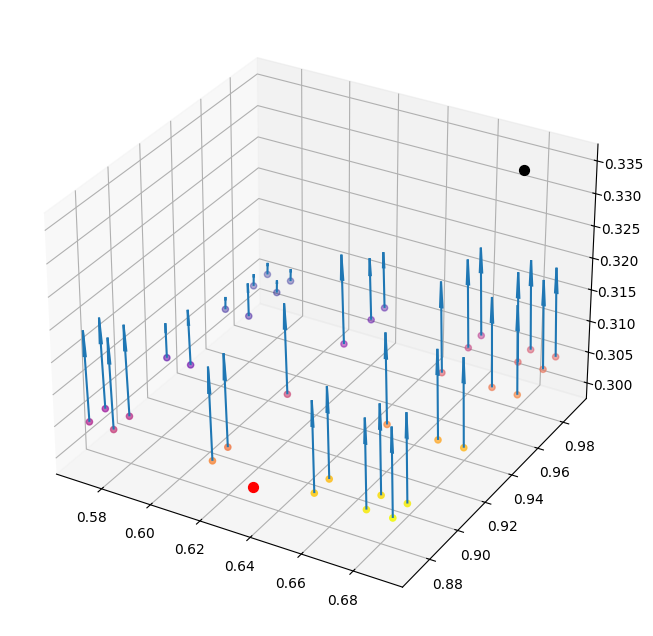

In [94]:
# Plots of reweighting loss landscape

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
# print(a_b_c)


# plot_nm = '19'
# issigma = True

# magnitudes = np.load(f'temp_results/Flow_map_nD/magnitudes_{plot_nm}.npy')
# a_b_gradients = np.load(f'temp_results/Flow_map_nD/gradients_{plot_nm}.npy')
# loss_grid = np.load(f'temp_results/Flow_map_nD/loss_grid_{plot_nm}.npy')
# mu_sigmamu = np.load(f'temp_results/Flow_map_nD/mu_{plot_nm}.npy')
# Neff = np.load(f'temp_results/Flow_map_nD/Neff_{plot_nm}.npy')
# mu = mu_sigmamu[:,0]
# sigmamu = mu_sigmamu[:,1]

# if issigma == False:
#     a_b_c = np.load(f'temp_results/Flow_map_nD/ad_bd_au_{plot_nm}.npy')
# else:
#     a_b_c = np.load(f'temp_results/Flow_map_nD/ad_bd_sig_{plot_nm}.npy')



#to save:
# Calculate the magnitude of each vector in a_b_gradients
magnitudes = np.linalg.norm(a_b_gradients, axis=1)
print(magnitudes.shape)

mu = metrics[0]
Neff = metrics[1]
np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/mu_24', mu)
np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/Neff_24', Neff)
np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/magnitudes_24',magnitudes)
np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/gradients_24',a_b_gradients)
np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/ad_bd_sig_24',a_b_c)
np.save('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/loss_grid_24',loss_grid)




fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ad = a_b_c[:,0]
bd = a_b_c[:,1]
sig = a_b_c[:,2]

g1,g2,g3 =  -a_b_gradients[:,0], -a_b_gradients[:,1], -a_b_gradients[:,2],
scale = 10e2
ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale)
# sc = ax.scatter(ad, bd, sig, c=magnitudes, cmap='plasma', s=20)  # 's' is size, 'c' is color
sc = ax.scatter(ad, bd, sig, c=np.log10((loss_grid)), cmap='plasma', s=20)  # 's' is size, 'c' is color
ax.scatter(0.68,0.98,0.335, label = 'base', c= 'black', s=50)
ax.scatter(0.63,0.88,0.300, label = 'target', c='red', s=50)


[[0.4        0.4        0.4        0.4        0.4        0.4
  0.4        0.4        0.4        0.4       ]
 [0.53333336 0.53333336 0.53333336 0.53333336 0.53333336 0.53333336
  0.53333336 0.53333336 0.53333336 0.53333336]
 [0.6666667  0.6666667  0.6666667  0.6666667  0.6666667  0.6666667
  0.6666667  0.6666667  0.6666667  0.6666667 ]
 [0.8        0.8        0.8        0.8        0.8        0.8
  0.8        0.8        0.8        0.8       ]
 [0.9333334  0.9333334  0.9333334  0.9333334  0.9333334  0.9333334
  0.9333334  0.9333334  0.9333334  0.9333334 ]
 [1.0666666  1.0666666  1.0666666  1.0666666  1.0666666  1.0666666
  1.0666666  1.0666666  1.0666666  1.0666666 ]
 [1.2        1.2        1.2        1.2        1.2        1.2
  1.2        1.2        1.2        1.2       ]
 [1.3333334  1.3333334  1.3333334  1.3333334  1.3333334  1.3333334
  1.3333334  1.3333334  1.3333334  1.3333334 ]
 [1.4666667  1.4666667  1.4666667  1.4666667  1.4666667  1.4666667
  1.4666667  1.4666667  1.4666667  1.4

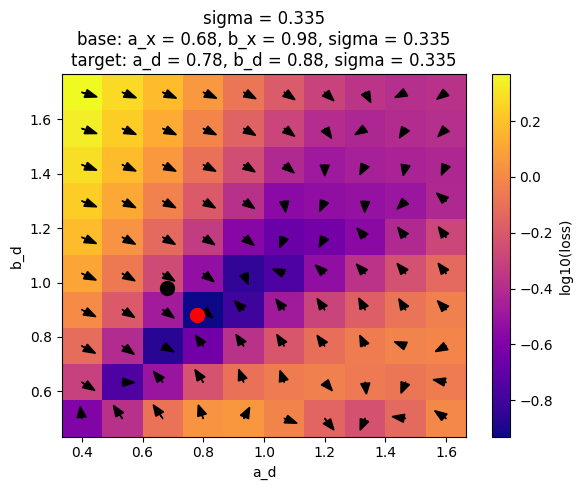

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Extract unique values for au
aus = np.unique(a_b_c[:, 2])
scale = 3e2

for a_value in aus:
    plt.figure(figsize=(6, 5))
    
    # Mask for current au slice
    mask = a_b_c[:, 2] == a_value
    ad = a_b_c[mask, 0]
    bd = a_b_c[mask, 1]
    ad_bd = np.vstack([ad,bd]).T
    a_b_grad_plot = a_b_gradients[mask]

    # Choose what to plot: mu/loss/N_eff
    loss_plot = np.log10((loss_grid))[mask]
    # loss_plot = ((mu))[mask][:,0]
    # loss_plot = ((Neff))[mask][:]

    # Get unique sorted grid values
    ad_unique = np.unique(ad)
    bd_unique = np.unique(bd)
    ad_grid, bd_grid = np.meshgrid(ad_unique, bd_unique, indexing='ij')
    print(ad_grid)

    # Reshape the loss values to fit the 2D grid
    loss_2d = loss_plot.reshape(len(ad_unique), len(bd_unique))
    # loss_2d -= (np.min(loss_2d))
    # loss_2d = np.log(loss_2d + 1e-1)

    # Plot
    cmap = plt.get_cmap('plasma')
    pc = plt.pcolormesh(ad_grid, bd_grid, loss_2d, shading='auto', cmap=cmap)

    for point, gradient in zip(ad_bd, a_b_grad_plot):
        plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[1]/scale, head_width=0.03, head_length=0.04, fc='k', ec='k')
    plt.plot(0.78, 0.88, marker='o', color='red', markersize=10, zorder=5)
    plt.plot(0.68, 0.98, marker='o', color='black', markersize=10, zorder=5)

    sig_label = r"$\ln \left( \left| \frac{1 - \mu}{\sigma_{1 - \mu}} \right| \right)$"
    plt.colorbar(label='log10(loss)')
    # plt.colorbar(label=sig_label)
    # plt.colorbar(label='Neff')
    # plt.title(f'a_u = {a_value:.2f}')
    plt.title(f'sigma = {a_value:.3f}\n'
          f'base: a_x = 0.68, b_x = 0.98, sigma = 0.335\n'
          f'target: a_d = 0.78, b_d = 0.88, sigma = 0.335')
    plt.xlabel('a_d')
    plt.ylabel('b_d')
    plt.tight_layout()
    # plt.savefig(f'temp_results/Flow_map_nD/plots/1Neff_au{a_value:.4f}.png')
    plt.show()


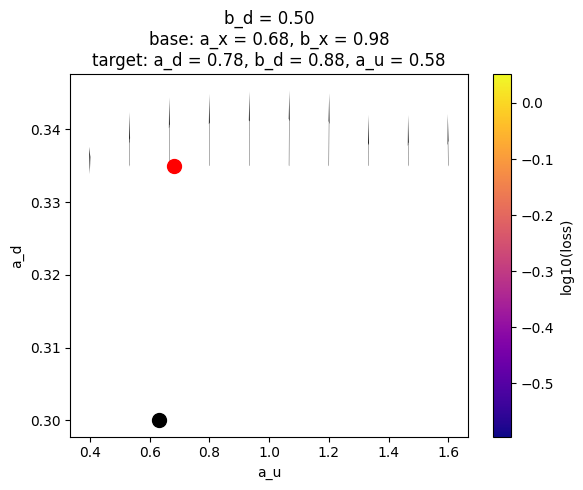

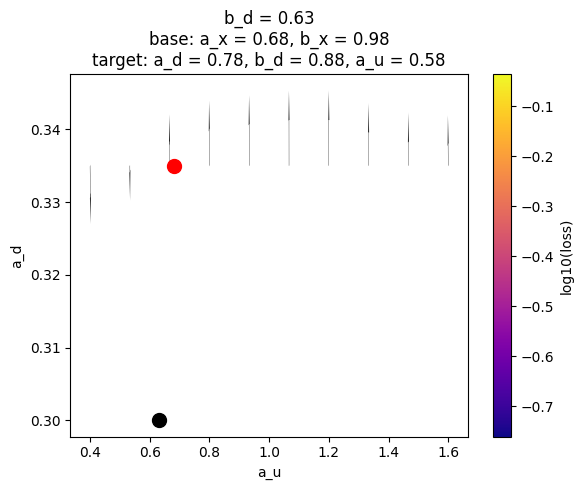

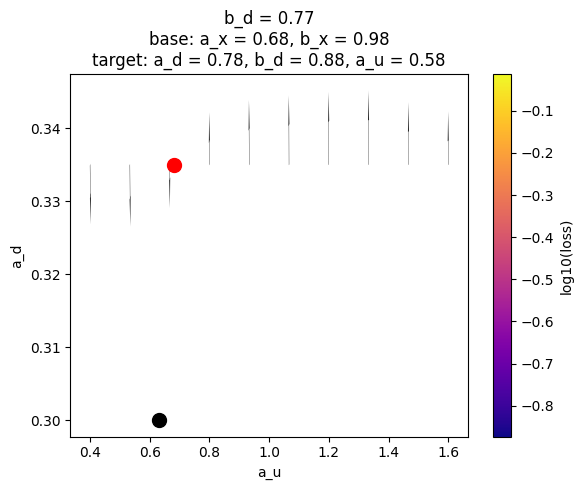

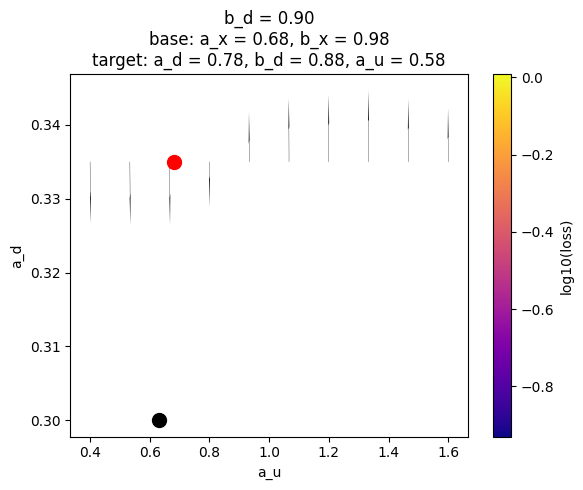

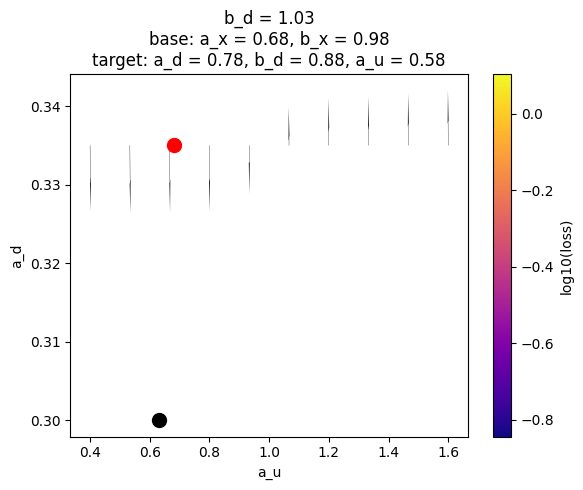

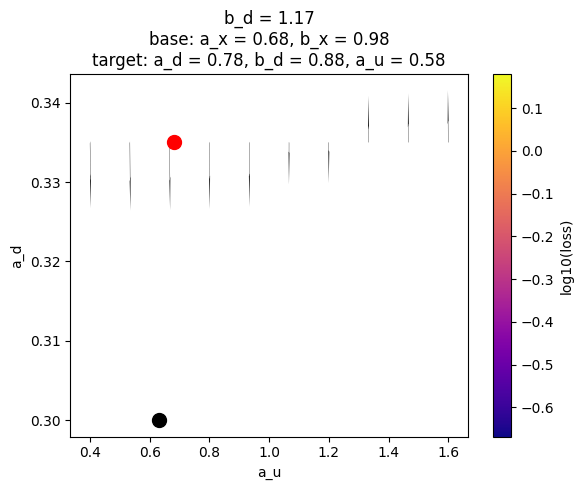

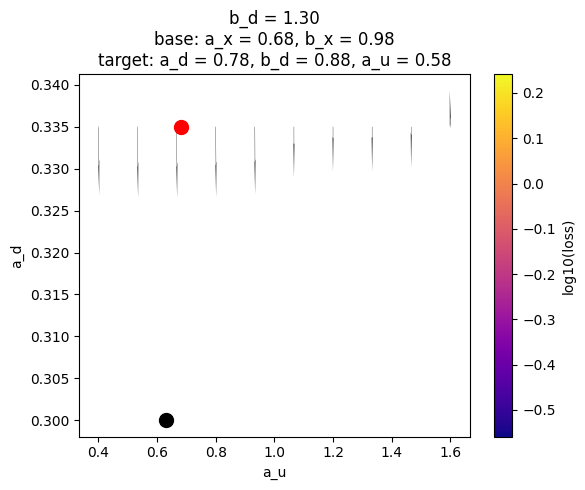

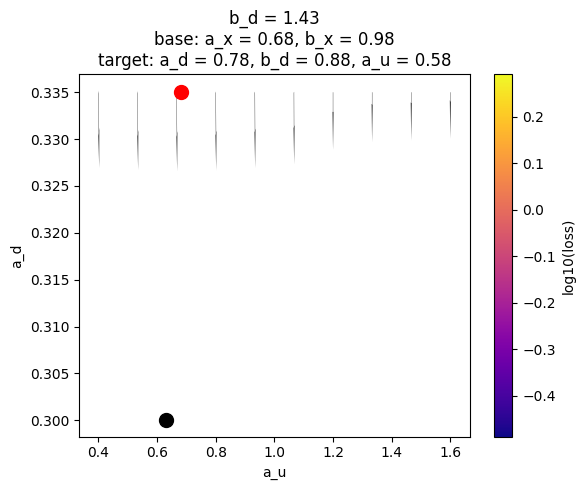

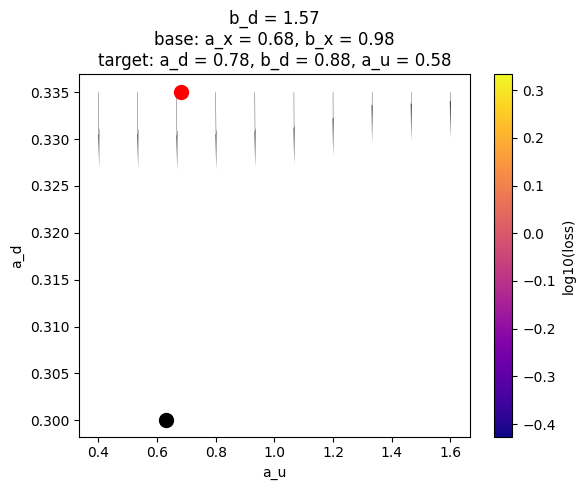

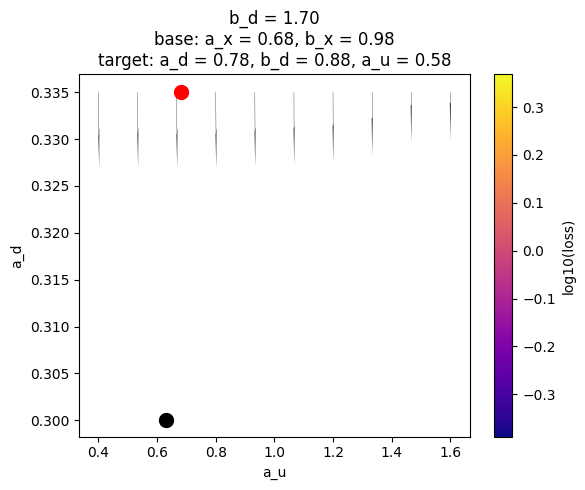

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Extract unique values for au
bds = np.unique(a_b_c[:, 1])
scale = 3e3
for b_value in bds:
    plt.figure(figsize=(6, 5))
    
    # Mask for current au slice
    mask = a_b_c[:, 1] == b_value
    ad = a_b_c[mask, 0]
    au = a_b_c[mask, 2]
    ad_au = np.vstack([ad,au]).T
    a_b_grad_plot = a_b_gradients[mask]

    loss_plot = np.log10((loss_grid))[mask]
    # loss_plot = ((Neff))[mask]

    # Get unique sorted grid values
    ad_unique = np.unique(ad)
    au_unique = np.unique(au)
    ad_grid, au_grid = np.meshgrid(ad_unique, au_unique, indexing='ij')

    # Reshape the loss values to fit the 2D grid
    loss_2d = loss_plot.reshape(len(ad_unique), len(au_unique))
    # loss_2d -= (np.min(loss_2d))
    # loss_2d = np.log(loss_2d + 1e-1)

    # Plot
    cmap = plt.get_cmap('plasma')
    pc = plt.pcolormesh(ad_grid, au_grid, loss_2d, shading='auto', cmap=cmap)

    for point, gradient in zip(ad_au, a_b_grad_plot):
        plt.arrow(point[0], point[1], -gradient[0]/scale, -gradient[2]/scale, linewidth=0.003, head_width=0.003, head_length=0.004, fc='k', ec='k')
    plt.plot(0.68, 0.335, marker='o', color='red', markersize=10, zorder=5)
    plt.plot(0.63, 0.300, marker='o', color='black', markersize=10, zorder=5)

    
    plt.colorbar(label='log10(loss)')
    plt.title(f'b_d = {b_value:.2f}\n'
          f'base: a_x = 0.68, b_x = 0.98\n'
          f'target: a_d = 0.78, b_d = 0.88, a_u = 0.58')
    plt.xlabel(r'a_u')
    plt.ylabel(r'a_d')
    plt.tight_layout()
    plt.savefig(f'temp_results/Flow_map_nD/plots/1_bd{b_value:.4f}.png')
    plt.show()

### Reweighting Performance Metrics

tensor([0.9674, 1.0034, 1.0005, 0.9929, 0.9848, 0.9799, 0.9768, 0.9714, 0.9627,
        0.9543, 0.9316, 0.9983, 1.0029, 0.9990, 0.9918, 0.9855, 0.9819, 0.9793,
        0.9759, 0.9723, 0.8832, 0.9829, 0.9987, 1.0005, 0.9963, 0.9904, 0.9857,
        0.9824, 0.9800, 0.9780, 0.8275, 0.9598, 0.9890, 0.9985, 0.9993, 0.9956,
        0.9911, 0.9873, 0.9843, 0.9821, 0.7671, 0.9307, 0.9736, 0.9923, 1.0001,
        1.0005, 0.9975, 0.9940, 0.9909, 0.9884, 0.7032, 0.8971, 0.9529, 0.9808,
        0.9971, 1.0036, 1.0038, 1.0013, 0.9984, 0.9960, 0.6362, 0.8598, 0.9282,
        0.9637, 0.9890, 1.0034, 1.0087, 1.0084, 1.0059, 1.0033, 0.5670, 0.8186,
        0.9007, 0.9415, 0.9750, 0.9982, 1.0105, 1.0143, 1.0131, 1.0101, 0.4965,
        0.7729, 0.8715, 0.9157, 0.9552, 0.9870, 1.0078, 1.0178, 1.0196, 1.0169,
        0.4264, 0.7220, 0.8405, 0.8878, 0.9306, 0.9697, 0.9990, 1.0169, 1.0241,
        1.0235])


Text(0, 0.5, '$b$')

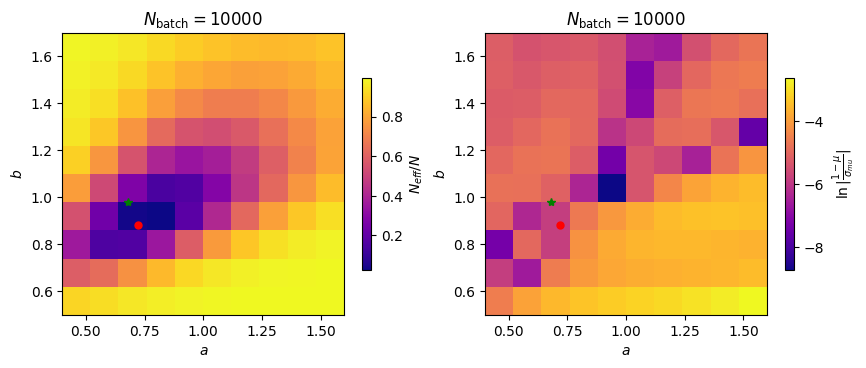

In [72]:
# Clone a_b_init into numpy array
a_b = a_b_init.detach().numpy()

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Calculate the magnitude of each vector in a_b_gradients
# magnitudes = np.linalg.norm(a_b_gradients, axis=1)

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Set the background color based on the magnitude
# Normalize the magnitude to use it with the colormap
# norm0 = mcolors.Normalize(vmin=np.min(magnitudes), vmax=np.max(magnitudes))
cmap = plt.cm.plasma  # Choose a colormap

# Assuming magnitudes can be reshaped into a grid directly for simplicity
# In a real scenario, you might need to interpolate these values onto a grid
N_eff = metrics[1].detach()
print(metrics[0].detach()[:,0])
mu = torch.log(abs(1-metrics[0].detach()[:,0]) / metrics[0].detach()[:,1])

grid_shape = (int(np.sqrt(len(N_eff))), int(np.sqrt(len(N_eff))))
N_eff_grid = 1 - N_eff.reshape(grid_shape).T
mu_grid = mu.reshape(grid_shape).T

# magnitudes_grid = magnitudes.reshape(grid_shape).T

# Create a heatmap of the gradient magnitudes

#metrics[0] -> mu_eff
#metrics[1] -> N_eff/N

#heatmap = ax.imshow(magnitudes_grid, cmap=cmap, norm=norm, origin='lower', extent=(np.min(a_b[:, 0]), np.max(a_b[:, 0]), np.min(a_b[:, 1]), np.max(a_b[:, 1])))
heatmap0 = ax[0].imshow(N_eff_grid, cmap=cmap, origin='lower', extent=(np.min(a_b[:, 0]), np.max(a_b[:, 0]), np.min(a_b[:, 1]), np.max(a_b[:, 1])))
heatmap1 = ax[1].imshow(mu_grid, cmap=cmap, origin='lower', extent=(np.min(a_b[:, 0]), np.max(a_b[:, 0]), np.min(a_b[:, 1]), np.max(a_b[:, 1])))
# heatmap = ax.imshow(metrics[1].detach().reshape(grid_shape).T, cmap=cmap, origin='lower', extent=(np.min(a_b[:, 0]), np.max(a_b[:, 0]), np.min(a_b[:, 1]), np.max(a_b[:, 1])))

# Add a colorbar to show the magnitude scale
fig.colorbar(heatmap0, ax=ax[0], label=r'$N_{eff}/N$', shrink=0.5)
fig.colorbar(heatmap1, ax=ax[1], label=r'$\ln{|\frac{1-\mu}{\sigma_{mu}}|}$', shrink=0.5)

a_b_target = np.array([0.68, 0.98]) # Monash
ax[0].plot(a_b_target[0], a_b_target[1], '*', color='green', label = 'Target', ms = 6, linewidth=10)
ax[0].plot(RSA.params_base[0].clone().detach().numpy(), RSA.params_base[1].clone().detach().numpy(), 'o', color = 'red', label = 'Base', ms = 5, linewidth=10)
ax[1].plot(a_b_target[0], a_b_target[1], '*', color='green', label = 'Target', ms = 6, linewidth=10)
ax[1].plot(RSA.params_base[0].clone().detach().numpy(), RSA.params_base[1].clone().detach().numpy(), 'o', color = 'red', label = 'Base', ms = 5, linewidth=10)

ax[0].set_title(rf'$N_{{\mathrm{{batch}}}} = {N_events}$')
ax[0].set_xlabel(r'$a$')
ax[0].set_ylabel(r'$b$')


ax[1].set_title(rf'$N_{{\mathrm{{batch}}}} = {N_events}$')
ax[1].set_xlabel(r'$a$')
ax[1].set_ylabel(r'$b$')

# fig.tight_layout()

### Flow Map for DeepSets Classifier

In [1]:
from RSA_tuner import *

class ObservableDataset(Dataset):
	"""
	Converts observable dataset into PyTorch syntax.
	"""
	def __init__(self, data):
		self.data = data

	def __len__(self):
		return self.data.shape[0]

	def __getitem__(self, idx):
		sample = self.data[idx]
		return sample

def a_b_grid(x_range, y_range, n_points):
    """
    Creates a grid of values within a two-dimensional range and returns it in a flattened tensor.

    Parameters:
    x_range (tuple): A tuple of (min, max) for the x-axis range.
    y_range (tuple): A tuple of (min, max) for the y-axis range.
    steps (int): --- The number of steps/points in each dimension.

    Returns:
    torch.Tensor: A flattened tensor containing all the grid points.
    """
    # Create linearly spaced points for each range
    x_points = torch.linspace(x_range[0], x_range[1], n_points)
    y_points = torch.linspace(y_range[0], y_range[1], n_points)

    # Create a meshgrid from the x and y points
    x_grid, y_grid = torch.meshgrid(x_points, y_points, indexing='ij')

    # Flatten the grid and stack the coordinates
    grid_flattened = torch.stack([x_grid.flatten(), y_grid.flatten()], dim=1)

    return grid_flattened

In [2]:
import sys
import os

# Add the directory containing deepsets_classifier.py to the Python path
current_path = os.getcwd()
sys.path.append(os.path.join(current_path, 'classifier'))

from deepsets_classifier import *


def prescale(exp_data, sim_data, axes=(0, 1)):
    """
    Prescale the experimental and simulated data using the combined mean and standard deviation.

    Args:
        exp_data (np.ndarray): The experimental data.
        sim_data (np.ndarray): The simulated data.
        axes (tuple): The axes along which to calculate the mean and standard deviation.

    Returns:
        np.ndarrays: The prescaled experimental and simulated data.
    """
    # Mask to identify non-padded entries (i.e., entries that are not [0.0, 0.0, 0.0, 0.0])
    non_padded_mask_exp = ~(np.all(exp_data == 0, axis=-1))
    non_padded_mask_sim = ~(np.all(sim_data == 0, axis=-1))
    
    # Flatten the non-padded parts of the datasets along the specified axes for mean/std calculation
    combined_data = np.concatenate([exp_data[non_padded_mask_exp], sim_data[non_padded_mask_sim]], axis=0)
    combined_mean = combined_data.mean(axis=0)
    print("Mean:", combined_mean)
    combined_std = combined_data.std(axis=0)

    # Scale only the non-padded entries using the combined mean and std
    exp_data_scaled = np.copy(exp_data)
    sim_data_scaled = np.copy(sim_data)
    exp_data_scaled[non_padded_mask_exp] = (exp_data[non_padded_mask_exp] - combined_mean) / combined_std
    sim_data_scaled[non_padded_mask_sim] = (sim_data[non_padded_mask_sim] - combined_mean) / combined_std
    
    return exp_data_scaled, sim_data_scaled

In [ ]:
# Paths to the datasets
exp_hadrons_PATH       = '/global/cfs/projectdirs/m3246/hadronization-tune-mlrw-data/RSA/pgun_qqbar_hadrons_a_0.64_b_1.08_sigma_0.335_N_5e5.npy'
# exp_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
sim_hadrons_PATH       = '/global/cfs/projectdirs/m3246/hadronization-tune-mlrw-data/RSA/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_5e5.npy'
# sim_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_accept_reject_PATH = '/global/cfs/projectdirs/m3246/hadronization-tune-mlrw-data/RSA/pgun_qqbar_accept_reject_z_a_0.72_b_0.88_sigma_0.335_N_5e5.npy'
# sim_accept_reject_PATH = '../data/structured_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_fPrel_PATH         = '/global/cfs/projectdirs/m3246/hadronization-tune-mlrw-data/RSA/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_5e5.npy'
# sim_fPrel_PATH         = '../data/structured_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'


# Load the arrays
exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# Print dataset shapes
print('Experimental observable shape:', exp_hadrons.shape)
# print('Experimental observable:', exp_hadrons[0,:]) #the first 10 hadrons and their 5 properties
print('Simulated observable shape:', sim_hadrons.shape)
print('Simulated z shape:', sim_accept_reject.shape)
print('Simulated fPrel shape:', sim_fPrel.shape)

# Restrict to a subset of the full dataset (for memory)
N_events = int(10000)
N = N_events


# Extract the hadron multiplicity
exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N)])
sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N)])

# Find the maximum multiplicity
min_mult = min(exp_mult.min(), sim_mult.min())
max_mult = max(exp_mult.max(), sim_mult.max())
print("Max multiplicity:", max_mult)

# Resize the zero-padding to the maximum multiplicity
exp_hadrons = exp_hadrons[:, :max_mult, :]
sim_hadrons = sim_hadrons[:, :max_mult, :]

# Extract (px, py, pz)
px_exp, py_exp, pz_exp = exp_hadrons[..., 0], exp_hadrons[..., 1], exp_hadrons[..., 2]
px_sim, py_sim, pz_sim = sim_hadrons[..., 0], sim_hadrons[..., 1], sim_hadrons[..., 2]

# Create masks for non-zero momentum entries
mask_exp = (px_exp != 0) | (py_exp != 0) | (pz_exp != 0)
mask_sim = (px_sim != 0) | (py_sim != 0) | (pz_sim != 0)

# Calculate transverse momentum (pT)
pt_exp = np.sqrt(px_exp**2 + py_exp**2)
pt_sim = np.sqrt(px_sim**2 + py_sim**2)

# Initialize arrays for the results with zeros
phi_exp = np.zeros_like(pt_exp)
phi_sim = np.zeros_like(pt_sim)
eta_exp = np.zeros_like(pt_exp)
eta_sim = np.zeros_like(pt_sim)

# Apply the calculations only where the mask is True (non-zero momentum)
phi_exp[mask_exp] = np.arctan2(py_exp[mask_exp], px_exp[mask_exp])
phi_sim[mask_sim] = np.arctan2(py_sim[mask_sim], px_sim[mask_sim])

theta_exp = np.arctan2(pt_exp[mask_exp], pz_exp[mask_exp])
theta_sim = np.arctan2(pt_sim[mask_sim], pz_sim[mask_sim])

eta_exp[mask_exp] = -np.log(np.tan(theta_exp / 2))
eta_sim[mask_sim] = -np.log(np.tan(theta_sim / 2))

# Define the new angular observable array (pT, phi, eta)
exp_obs = np.stack([pt_exp, phi_exp, eta_exp], axis=-1)
sim_obs = np.stack([pt_sim, phi_sim, eta_sim], axis=-1)

# Print dataset shapes
print('Experimental observable shape:', exp_obs.shape)
print('Simulated observable shape:', sim_obs.shape)

# Prescale the data
N_events = int(10000)
exp_obs, sim_obs = prescale(exp_obs[0:N_events], sim_obs[0:N_events])

# Convert into torch objects
exp_obs = torch.Tensor(exp_obs.copy())
sim_obs = torch.Tensor(sim_obs.copy())


Experimental observable shape: (10000, 75, 5)
Simulated observable shape: (10000, 75, 5)
Simulated z shape: (10000, 105, 101)
Simulated fPrel shape: (10000, 105, 100)
Max multiplicity: 29
[[ 0.54978656  1.81045608  3.84708428]
 [ 0.68834666 -1.37154686  3.76468222]
 [ 0.26229403  0.44257044  4.8359985 ]
 [ 0.11625336  1.40478106  3.75503296]
 [ 0.55249139 -2.78001888  1.94974145]
 [ 0.42824008 -0.44679798  1.55407142]
 [ 0.36878593  0.95601935 -1.36120837]
 [ 0.62135474  1.96057035 -1.77486256]
 [ 0.60891043 -1.5757365  -2.06401172]
 [ 0.40339869 -2.06668914 -1.84683292]
 [ 0.4560741   1.67324016 -1.43789995]
 [ 0.21996211 -0.1906903  -1.39976286]
 [ 0.350889   -1.99947557 -4.38271262]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.   

In [4]:
# Define the DeepSets classifier hyperparameters (that match the pre-trained model)
input_dim      = 3
phi_hidden_dim = 32
rho_hidden_dim = 63
phi_layers     = 5
rho_layers     = 3
dropout_prob   = 0.5
mask_pad       = True
device         = 'cpu'

# Initialize the DeepSets classifier
classifier = DeepSetsClassifier(input_dim=input_dim, phi_hidden_dim=phi_hidden_dim, rho_hidden_dim=rho_hidden_dim,
                                phi_layers=phi_layers, rho_layers=rho_layers, device=device,
                                dropout_prob=dropout_prob, mask_pad=mask_pad).to(device)

# Load the pre-trained model
classifier.load_state_dict(torch.load("classifier/model/deepsets_classifier.pth", map_location=torch.device('cpu')))

Number of learnable parameters: 11671


/var/folders/1l/8qyzjsmx231gm5fbpjts8n6c0000gn/T/ipykernel_41239/4176766026.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load("class

<All keys matched successfully>

cpu
cpu


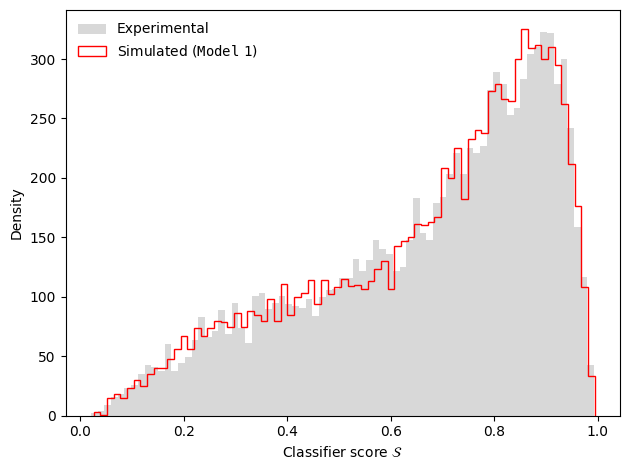

In [5]:
# Set to eval mode
classifier.eval()

# Extract the scores
exp_scores = torch.sigmoid(classifier.forward(exp_obs[:N_events], device="cpu")).to(device).detach()
sim_scores = torch.sigmoid(classifier.forward(sim_obs[:N_events], device="cpu")).to(device).detach()

# Plot the classifier scores
fig, ax = plt.subplots(1,1)
ax.hist(exp_scores.cpu().numpy(), bins=75, histtype='stepfilled', label='Experimental', color='gray', alpha=0.3)
ax.hist(sim_scores.cpu().numpy(), bins=75, histtype='step', label=r'Simulated ($\mathtt{Model}$ $\mathtt{1}$)', color='red')
ax.set_xlabel(r'Classifier score $\mathcal{S}$')
ax.set_ylabel('Density')
ax.legend(frameon=False)
fig.tight_layout()

In [6]:

# Convert into torch objects
sim_scores          = torch.Tensor(sim_scores[0:N_events].clone())
sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
exp_scores          = torch.Tensor(exp_scores[0:N_events].clone())

# Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
# The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
# z = 1, this term diverges to -inf and completely destroys the backward pass.
epsilon = 1e-5
sim_accept_reject[sim_accept_reject == 1] = 1 - epsilon

# Print dataset shapes
print('Experimental scores shape:', exp_scores.shape)
print('Experimental scores:', exp_scores[:10])
print('Simulated scores shape:', sim_scores.shape)
print('Simulated scores:', sim_scores[:10])
print('Simulated z shape:', sim_accept_reject.shape) # only has the z values, accepted and rejected
# print('Simulated z:', sim_accept_reject[0,0,:])
print('Simulated fPrel shape:', sim_fPrel.shape)

# Prepare data for DataLoader
sim_scores        = ObservableDataset(sim_scores)
sim_accept_reject = ObservableDataset(sim_accept_reject)
sim_mT            = ObservableDataset(sim_fPrel)
exp_scores        = ObservableDataset(exp_scores)

Experimental scores shape: torch.Size([10000])
Experimental scores: tensor([0.8984, 0.9646, 0.8576, 0.9412, 0.8053, 0.6891, 0.1323, 0.6400, 0.8865,
        0.0519])
Simulated scores shape: torch.Size([10000])
Simulated scores: tensor([0.8863, 0.5388, 0.6320, 0.8146, 0.8619, 0.4893, 0.5853, 0.7777, 0.8969,
        0.7812])
Simulated z shape: torch.Size([10000, 105, 101])
Simulated fPrel shape: torch.Size([10000, 105, 100])


In [7]:
# Set batch size -- set it eqaul to the number of events, we only want one 'batch'
batch_size = N_events

# Initialize data-loaders
sim_observable_dataloader    = DataLoader(sim_scores,          batch_size = batch_size, shuffle = False)
sim_accept_reject_dataloader = DataLoader(sim_accept_reject, batch_size = batch_size, shuffle = False)
sim_fPrel_dataloader         = DataLoader(sim_fPrel,         batch_size = batch_size, shuffle = False)
exp_observable_dataloader    = DataLoader(exp_scores,          batch_size = batch_size, shuffle = False)

print('Size of sim_observable_dataloader:', len(sim_observable_dataloader.dataset))
print('Size of sim_accept_reject_dataloader:', len(sim_accept_reject_dataloader.dataset))
print('Size of sim_fPrel_dataloader:', len(sim_fPrel_dataloader.dataset))
print('Size of exp_observable_dataloader:', len(exp_observable_dataloader.dataset))
print('Shape of sim_observable_dataloader:', sim_accept_reject_dataloader.dataset.data.shape)

Size of sim_observable_dataloader: 10000
Size of sim_accept_reject_dataloader: 10000
Size of sim_fPrel_dataloader: 10000
Size of exp_observable_dataloader: 10000
Shape of sim_observable_dataloader: torch.Size([10000, 105, 101])


In [8]:
# Training hyperparameters
over_sample_factor = 10.0
# The flow map will be dependent on the learning rate (size of the gradients)
learning_rate = 0.01
fixed_binning = True
# Length of event buffer
dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

print('Each event has been zero-padded to a length of', dim_multiplicity)
print('Each emission has been zero-padded to a length of', dim_accept_reject)

# Define base parameters of simulated data (a, b)
params_base = torch.tensor([0.72, 0.88])
# Define a grid of initial parameters
a_range  = (0.6-0.1, 0.80+0.1)#(0.6, 0.80)
b_range  = (0.85-0.1, 1.05+0.1)#(0.85, 1.05)
n_points = 5
a_b_init = a_b_grid(a_range, b_range, n_points)

Each event has been zero-padded to a length of 105
Each emission has been zero-padded to a length of 101


In [9]:
print('Initial a_b grid shape:', a_b_init.shape)
# print('Initial a_b grid:', a_b_init)

Initial a_b grid shape: torch.Size([25, 2])


In [10]:
# Irrelevant parameters for the flow plot that must be initialized for the RSA class
epochs = 1

# Create an RSA instance
RSA = RSA_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
				params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
				sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = True, 
				results_dir = "/Users/lukapuslar/Desktop/other/ASEF/Project/Code/RSA/RSA/src/temp_results", params_init = None, fixed_binning = False)


In [36]:
# Set the optimizer
optimizer = torch.optim.Adam(RSA.weight_nexus.parameters(), lr=learning_rate)
#optimizer = torch.optim.SGD(macroscopic_trainer.weight_nexus.parameters(), lr=learning_rate)

# Generate gradients
a_b_gradients, loss_grid = RSA.RSA_flow(optimizer, a_b_c_init)

NameError: name 'a_b_c_init' is not defined

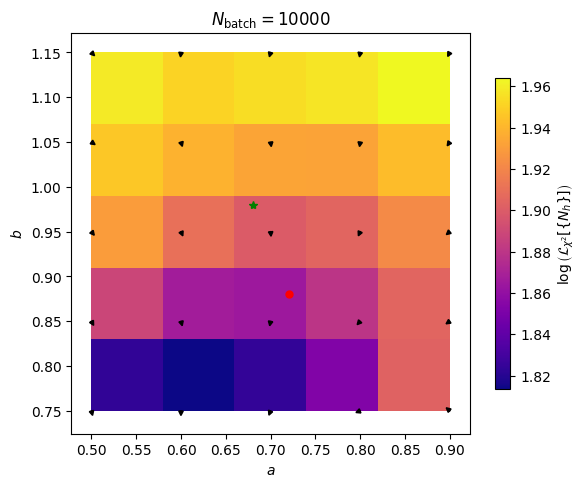

In [12]:
# Clone a_b_init into numpy array
a_b = a_b_init.detach().numpy()

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Calculate the magnitude of each vector in a_b_gradients
magnitudes = np.linalg.norm(a_b_gradients, axis=1)

fig, ax = plt.subplots(1,1,figsize=(6,5))

# Set the background color based on the magnitude
# Normalize the magnitude to use it with the colormap
norm = mcolors.Normalize(vmin=np.min(magnitudes), vmax=np.max(magnitudes))
cmap = plt.cm.plasma  # Choose a colormap

# Assuming magnitudes can be reshaped into a grid directly for simplicity
# In a real scenario, you might need to interpolate these values onto a grid
grid_shape = (int(np.sqrt(len(magnitudes))), int(np.sqrt(len(magnitudes))))
magnitudes_grid = magnitudes.reshape(grid_shape).T

# Create a heatmap of the gradient magnitudes
#heatmap = ax.imshow(magnitudes_grid, cmap=cmap, norm=norm, origin='lower', extent=(np.min(a_b[:, 0]), np.max(a_b[:, 0]), np.min(a_b[:, 1]), np.max(a_b[:, 1])))
heatmap = ax.imshow(np.log10((loss_grid * N_events)).reshape(grid_shape).T, cmap=cmap, origin='lower', extent=(np.min(a_b[:, 0]), np.max(a_b[:, 0]), np.min(a_b[:, 1]), np.max(a_b[:, 1])))

# Add a colorbar to show the magnitude scale
fig.colorbar(heatmap, ax=ax, label=r'$\log \left(\mathcal{L}_{\chi^2}[\{ N_h \}]\right)$', shrink=0.75)

# Plot arrows for each point and direction
for point, gradient in zip(a_b, a_b_gradients):
    ax.arrow(point[0], point[1], -gradient[0]/5e1, -gradient[1]/5e1, head_width=0.005, head_length=0.005, fc='k', ec='k')

a_b_target = np.array([0.68, 0.98]) # Monash
ax.plot(a_b_target[0], a_b_target[1], '*', color='green', label = 'Target', ms = 6, linewidth=10)
ax.plot(RSA.params_base[0].clone().detach().numpy(), RSA.params_base[1].clone().detach().numpy(), 'o', color = 'red', label = 'Base', ms = 5, linewidth=10)

ax.set_title(rf'$N_{{\mathrm{{batch}}}} = {N_events}$')
ax.set_xlabel(r'$a$')
ax.set_ylabel(r'$b$')

fig.tight_layout()